# 🏡 House Wizard: Real Estate Price Prediction Pipeline

Welcome to the **House Wizard** project. This notebook outlines a complete Machine Learning pipeline designed to predict real estate prices accurately. The workflow follows a strict, logical sequence from raw data to final model evaluation:

1. **Data Preprocessing & Exploration:** Cleaning the data, handling missing values, and preparing features for modeling.
2. **Pipeline Construction:** Setting up algorithms with integrated feature scaling and target transformation.
3. **Model Training:** Fitting the data to the selected algorithms.
4. **Evaluation & Visualization:** Assessing performance using industry-standard metrics and residual plots.
5. **Cross-Validation:** Ensuring model stability and preventing overfitting using K-Fold validation.

## 1. Data Preprocessing and Feature Engineering

Before feeding data into any Machine Learning algorithm, it must be cleaned and structured. In this section, we perform essential data operations:
* **Handling Missing Values:** Ensuring no null values disrupt the algorithms.
* **Feature Selection/Encoding:** Preparing categorical variables and selecting the most impactful numerical features.
* **Train-Test Split:** Dividing the dataset to ensure we have unseen data for final model evaluation.

### 🔍 Outlier Detection and Visual Analysis

Identifying outliers is a critical step in our Exploratory Data Analysis (EDA). Extreme, unrepresentative values can heavily skew the performance of our regression models, particularly distance-based algorithms like KNN and SVR. 

In this section, we utilize two primary visualization techniques on the Ames Housing dataset:
* **Boxplots:** To visualize the spread of our target variable (`SalePrice`) and easily spot data points falling outside the Interquartile Range (IQR).
* **Scatter Plots:** To identify bivariate outliers by visualizing the relationship between the target variable (`SalePrice`) and the primary spatial feature (`Gr Liv Area`).

In [3]:
import pandas as pd
import numpy as np
########################################
df = pd.read_csv("AmesHousing.csv")
display(df)
print(df.shape)
########################################
df.isna().sum()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


(2930, 82)


Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

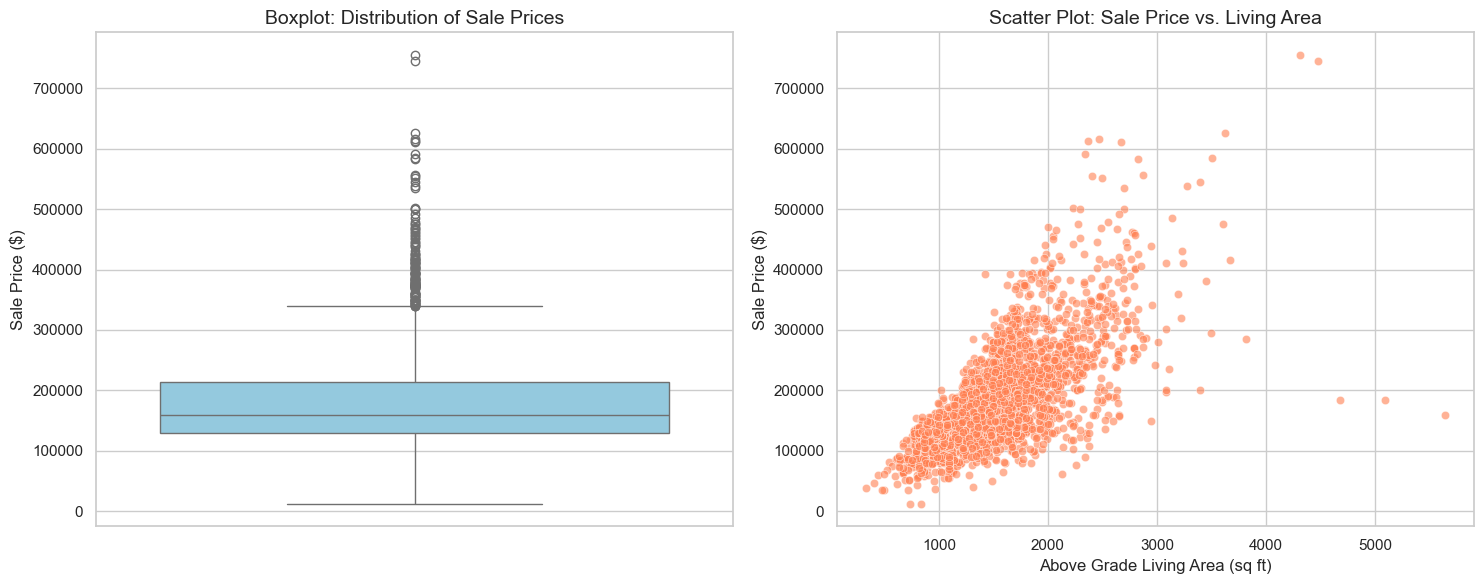

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for cleaner graphs
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 1. Boxplot: To find outliers in the target variable (SalePrice) ---
# Changed 'x' to 'y' to make the boxplot vertical (Price on Y-axis)
sns.boxplot(y=df['SalePrice'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot: Distribution of Sale Prices', fontsize=14)
axes[0].set_ylabel('Sale Price ($)', fontsize=12)

# --- 2. Scatter Plot: To find bivariate outliers (SalePrice vs. Gr Liv Area) ---
# Price is already on the Y-axis and Area is on the X-axis here
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'], alpha=0.6, color='coral', ax=axes[1])
axes[1].set_title('Scatter Plot: Sale Price vs. Living Area', fontsize=14)
axes[1].set_xlabel('Above Grade Living Area (sq ft)', fontsize=12)
axes[1].set_ylabel('Sale Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

### 📝 Interpretation of Visualization Results

After generating the plots, we can observe the following regarding the **Ames Housing** data distribution:

1.  **Vertical Boxplot (SalePrice):**
    * The central box represents the **Interquartile Range (IQR)**, where the majority of house prices fall.
    * The individual points located above the top "whisker" are **univariate outliers**. These represent luxury properties with significantly higher prices than the market average.

2.  **Scatter Plot (Price vs. Living Area):**
    * There is a clear positive correlation: as the `Gr Liv Area` (square footage) increases, the `SalePrice` generally tends to increase.
    * **Bivariate Outliers:** Pay close attention to any data points in the bottom-right corner. These represent houses with very large living areas but unusually low sale prices. In the Ames dataset, these are often partial sales or agricultural properties that do not follow the general market trend.



### 🚩 Next Steps: Outlier Removal
To ensure our **LinearRegressor**, **SVR** and **KNN** models are not misled by these extreme values, we should consider filtering the dataset. A common practice for this specific dataset is to remove properties with more than **3500 sq ft** of living area that do not follow the price trend, as recommended by the dataset's documentation.

In [5]:
df.drop(columns = ["PID","Order"], inplace = True)
df = df[df['Gr Liv Area'] < 3500]

### 🗂️ Feature Segregation: Numerical vs. Categorical

In this step, we will separate the dataset's columns into two distinct groups: **Numerical** (quantitative) and **Categorical** (text/qualitative) features. 

**Why is this necessary?**
Machine Learning models inherently require numerical input to perform mathematical computations. Therefore, we must treat these two types of data differently during the preprocessing phase:
* **Numerical Features:** Often require scaling or normalization (e.g., `MinMaxScaler` or `StandardScaler`) so that features with larger magnitudes do not dominate the model.
* **Categorical Features:** Must be converted into a numerical format using encoding techniques (e.g., `OneHotEncoder` or `OrdinalEncoder`) before they can be mathematically processed by the algorithms.

In [6]:
dfs = df.drop(columns = df.select_dtypes("number").columns.tolist())
dfn = df.select_dtypes("number")
dfs

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,P,NaN,NaN,NaN,WD,Normal
1,RH,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,Gar2,WD,Normal
3,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,Fin,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,Detchd,Unf,TA,TA,Y,NaN,GdPrv,NaN,WD,Normal
2926,RL,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2927,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,NaN,NaN,NaN,NaN,Y,NaN,MnPrv,Shed,WD,Normal
2928,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


### 🔢 Categorical Data Encoding Strategy

Machine learning algorithms are mathematically driven and can only process numerical data. Since our categorical columns currently contain text, we must translate them into a numerical format. 

To determine the most effective encoding technique, we will first inspect the **unique values** within each categorical feature. This exploration guides our encoding strategy:

* **Ordinal Encoding:** Applied to categorical features that possess a natural, inherent order or ranking (e.g., Quality ratings like "Poor", "Average", "Good", "Excellent"). This preserves the hierarchical relationship between the categories.
* **One-Hot Encoding (`pd.get_dummies`):** Applied to nominal categorical features that have no specific order or ranking (e.g., "Neighborhood", "Roof Style"). This prevents the model from incorrectly assuming a mathematical relationship between independent categories.

In [7]:
for col in dfs.columns:
    print (col,df[col].unique().tolist())

MS Zoning ['RL', 'RH', 'FV', 'RM', 'C (all)', 'I (all)', 'A (agr)']
Street ['Pave', 'Grvl']
Alley [nan, 'Pave', 'Grvl']
Lot Shape ['IR1', 'Reg', 'IR2', 'IR3']
Land Contour ['Lvl', 'HLS', 'Bnk', 'Low']
Utilities ['AllPub', 'NoSewr', 'NoSeWa']
Lot Config ['Corner', 'Inside', 'CulDSac', 'FR2', 'FR3']
Land Slope ['Gtl', 'Mod', 'Sev']
Neighborhood ['NAmes', 'Gilbert', 'StoneBr', 'NWAmes', 'Somerst', 'BrDale', 'NPkVill', 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW', 'Sawyer', 'Greens', 'BrkSide', 'OldTown', 'IDOTRR', 'ClearCr', 'SWISU', 'Edwards', 'CollgCr', 'Crawfor', 'Blueste', 'Mitchel', 'Timber', 'MeadowV', 'Veenker', 'GrnHill', 'Landmrk']
Condition 1 ['Norm', 'Feedr', 'PosN', 'RRNe', 'RRAe', 'Artery', 'PosA', 'RRAn', 'RRNn']
Condition 2 ['Norm', 'Feedr', 'PosA', 'PosN', 'Artery', 'RRNn', 'RRAe', 'RRAn']
Bldg Type ['1Fam', 'TwnhsE', 'Twnhs', 'Duplex', '2fmCon']
House Style ['1Story', '2Story', '1.5Fin', 'SFoyer', 'SLvl', '2.5Unf', '1.5Unf', '2.5Fin']
Roof Style ['Hip', 'Gable', 'Mansard', 

### 🗺️ Ordinal Feature Mapping: Preserving Hierarchy

Based on our exploration of the categorical unique values, several features exhibit a clear hierarchical order. These typically fall into two categories within the Ames dataset:
* **Quality and Condition Ratings:** Standardized evaluations of property features (e.g., `Ex` = Excellent, `Gd` = Good, `TA` = Typical/Average, `Fa` = Fair, `Po` = Poor, `No-NA-np.nan`= 0 ---> (clever way to reduce null cells)).
* **Custom Sequential Features:** Features with a specific, logical progression (e.g., Basement exposure levels or Garage finish types).

To accurately capture this inherent ranking, we will apply **custom dictionary mapping**. By manually assigning numerical weights (e.g., Poor = 1, Excellent = 5), we ensure the regression models correctly interpret the magnitude and order of these features. This manual mapping is crucial, as automated label encoders often sort alphabetically, which would destroy the logical relationship between the categories.

In [8]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
expo_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0, np.nan: 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1, np.nan: 0}
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1, np.nan: 0}
util_map = {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1, np.nan: 0}
func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0, np.nan: 7}
paved_map = {'Y': 2, 'P': 1, 'N': 0, np.nan: 0}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0, np.nan: 0}

qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']

for col in qual_cols:
    dfs[col] = dfs[col].map(qual_map)

mappings = {
    'Bsmt Exposure': expo_map,
    'BsmtFin Type 1': bsmt_fin_map,
    'BsmtFin Type 2': bsmt_fin_map,
    'Garage Finish': garage_fin_map,
    'Lot Shape': shape_map,
    'Land Slope': slope_map,
    'Utilities': util_map,
    'Functional': func_map,
    'Paved Drive': paved_map,
    'Fence': fence_map
}

for col, mapping in mappings.items():
    dfs[col] = dfs[col].map(mapping)
dfs.info()

<class 'pandas.DataFrame'>
Index: 2920 entries, 0 to 2929
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MS Zoning       2920 non-null   str  
 1   Street          2920 non-null   str  
 2   Alley           198 non-null    str  
 3   Lot Shape       2920 non-null   int64
 4   Land Contour    2920 non-null   str  
 5   Utilities       2920 non-null   int64
 6   Lot Config      2920 non-null   str  
 7   Land Slope      2920 non-null   int64
 8   Neighborhood    2920 non-null   str  
 9   Condition 1     2920 non-null   str  
 10  Condition 2     2920 non-null   str  
 11  Bldg Type       2920 non-null   str  
 12  House Style     2920 non-null   str  
 13  Roof Style      2920 non-null   str  
 14  Roof Matl       2920 non-null   str  
 15  Exterior 1st    2920 non-null   str  
 16  Exterior 2nd    2920 non-null   str  
 17  Mas Vnr Type    1149 non-null   str  
 18  Exter Qual      2920 non-null   int64
 19  E

### 🔄 Feature Integration & Nominal Data Encoding

With the ordinal features successfully mapped to numerical weights, we must update our dataset structure before proceeding to model training:

1. **Integrating Ordinal Features:** We reassign the newly mapped ordinal columns into the pool of numerical features. Since they now possess mathematical significance (both magnitude and order), they are ready to be treated as continuous variables and scaled accordingly.
2. **One-Hot Encoding Nominal Features:** For the remaining categorical columns—which are strictly nominal and have no inherent ranking (e.g., Neighborhood, Roof Style)—we apply One-Hot Encoding using `pd.get_dummies()`. This technique converts each unique category into a separate binary column (0 or 1), ensuring the regression models do not falsely assume any mathematical hierarchy between these discrete categories.

In [9]:
for col in dfs.select_dtypes("number").columns:
    dfn[col] = dfs[col]
    dfs.drop(columns = col, inplace = True)
dfs = pd.get_dummies(dfs, dtype = int, drop_first=True)
dfn.info()
print('\n')
dfs.info()

<class 'pandas.DataFrame'>
Index: 2920 entries, 0 to 2929
Data columns (total 57 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2920 non-null   int64  
 1   Lot Frontage     2430 non-null   float64
 2   Lot Area         2920 non-null   int64  
 3   Overall Qual     2920 non-null   int64  
 4   Overall Cond     2920 non-null   int64  
 5   Year Built       2920 non-null   int64  
 6   Year Remod/Add   2920 non-null   int64  
 7   Mas Vnr Area     2897 non-null   float64
 8   BsmtFin SF 1     2919 non-null   float64
 9   BsmtFin SF 2     2919 non-null   float64
 10  Bsmt Unf SF      2919 non-null   float64
 11  Total Bsmt SF    2919 non-null   float64
 12  1st Flr SF       2920 non-null   int64  
 13  2nd Flr SF       2920 non-null   int64  
 14  Low Qual Fin SF  2920 non-null   int64  
 15  Gr Liv Area      2920 non-null   int64  
 16  Bsmt Full Bath   2919 non-null   float64
 17  Bsmt Half Bath   2919 non-null

### 🏗️ Final Dataset Consolidation

At this stage, all features have been successfully transformed into a machine-readable numerical format. The final step in our preprocessing pipeline is to concatenate the originally continuous numerical columns, the newly weighted ordinal columns, and the one-hot encoded dummy variables back into a single, unified DataFrame. 

This consolidated dataset is now fully sanitized, strictly numerical, and perfectly structured to be split into training and testing sets for model development.

In [10]:
dff = pd.concat([dfs, dfn], axis=1)
dff

,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Pave,Alley_Pave,Land Contour_HLS,Land Contour_Low,...,Heating QC,Kitchen Qual,Functional,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence
0,0,0,0,0,1,0,1,0,0,0,...,2,3,7,4,3,3,3,1,0,0
1,0,0,0,1,0,0,1,0,0,0,...,3,3,7,0,1,3,3,2,0,3
2,0,0,0,0,1,0,1,0,0,0,...,3,4,7,0,1,3,3,2,0,0
3,0,0,0,0,1,0,1,0,0,0,...,5,5,7,3,3,3,3,2,0,0
4,0,0,0,0,1,0,1,0,0,0,...,4,3,7,3,3,3,3,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,0,0,0,0,1,0,1,0,0,0,...,3,3,7,0,1,3,3,2,0,4
2926,0,0,0,0,1,0,1,0,0,1,...,3,3,7,0,1,3,3,2,0,3
2927,0,0,0,0,1,0,1,0,0,0,...,3,3,7,0,0,0,0,2,0,3
2928,0,0,0,0,1,0,1,0,0,0,...,4,3,7,3,2,3,3,2,0,0


### 🛠️ Advanced Data Imputation using KNN

As a final safeguard for our numerical features, we implement the **KNNImputer**. Despite our initial preprocessing, some numerical columns might still contain subtle missing values (NaNs) that were overlooked or emerged during feature integration.

**Why KNN Imputer?**
Unlike simple imputation methods (like filling with Mean or Median), the **K-Nearest Neighbors Imputer** is a multivariate approach. It estimates missing values by finding the $k$ most similar data points in the multi-dimensional feature space. This ensures that the imputed values are statistically consistent with the overall characteristics of each specific property, maintaining the integrity of our dataset before it enters the model training phase.

In [11]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=2)
cools = dff.columns
dff = imputer.fit_transform(dff)
dff = pd.DataFrame(dff, columns = cools)
dff.isna().sum()

MS Zoning_C (all)    0
MS Zoning_FV         0
MS Zoning_I (all)    0
MS Zoning_RH         0
MS Zoning_RL         0
                    ..
Garage Qual          0
Garage Cond          0
Paved Drive          0
Pool QC              0
Fence                0
Length: 207, dtype: int64

### 🎯 Feature Selection via Correlation Analysis

After the encoding and imputation phases, our feature space has expanded significantly to **207 columns**. While more data can be beneficial, such high dimensionality often introduces "noise" and increases the risk of overfitting, where the model memorizes patterns that do not generalize well.

To streamline our model and improve its predictive power, we perform **Dimensionality Reduction** based on the **Pearson Correlation Coefficient**. We will filter the features to retain only those that demonstrate a strong linear relationship with the target variable (`SalePrice`). 

**The Selection Criteria:**
* We establish a threshold of **0.50 (50%)**. 
* Only features with a correlation magnitude greater than this threshold are preserved.
* This ensures that our models (SVR, KNN, and Linear Regression) focus exclusively on the most statistically significant drivers of property value, leading to a more efficient, interpretable, and robust prediction engine.

<class 'pandas.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Overall Qual   2920 non-null   float64
 1   Year Built     2920 non-null   float64
 2   Total Bsmt SF  2920 non-null   float64
 3   Gr Liv Area    2920 non-null   float64
 4   Garage Yr Blt  2920 non-null   float64
 5   Garage Cars    2920 non-null   float64
 6   Garage Area    2920 non-null   float64
 7   SalePrice      2920 non-null   float64
 8   Exter Qual     2920 non-null   float64
 9   Bsmt Qual      2920 non-null   float64
 10  Kitchen Qual   2920 non-null   float64
dtypes: float64(11)
memory usage: 251.1 KB


None

,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Yr Blt,Garage Cars,Garage Area,SalePrice,Exter Qual,Bsmt Qual,Kitchen Qual
0,6.0,1960.0,1080.0,1656.0,1960.0,2.0,528.0,215000.0,3.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1961.0,1.0,730.0,105000.0,3.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1958.0,1.0,312.0,172000.0,3.0,3.0,4.0
3,7.0,1968.0,2110.0,2110.0,1968.0,2.0,522.0,244000.0,4.0,3.0,5.0
4,5.0,1997.0,928.0,1629.0,1997.0,2.0,482.0,189900.0,3.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,1984.0,2.0,588.0,142500.0,3.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,1983.0,2.0,484.0,131000.0,3.0,4.0,3.0
2917,5.0,1992.0,912.0,970.0,1962.5,0.0,0.0,132000.0,3.0,4.0,3.0
2918,5.0,1974.0,1389.0,1389.0,1975.0,2.0,418.0,170000.0,3.0,4.0,3.0


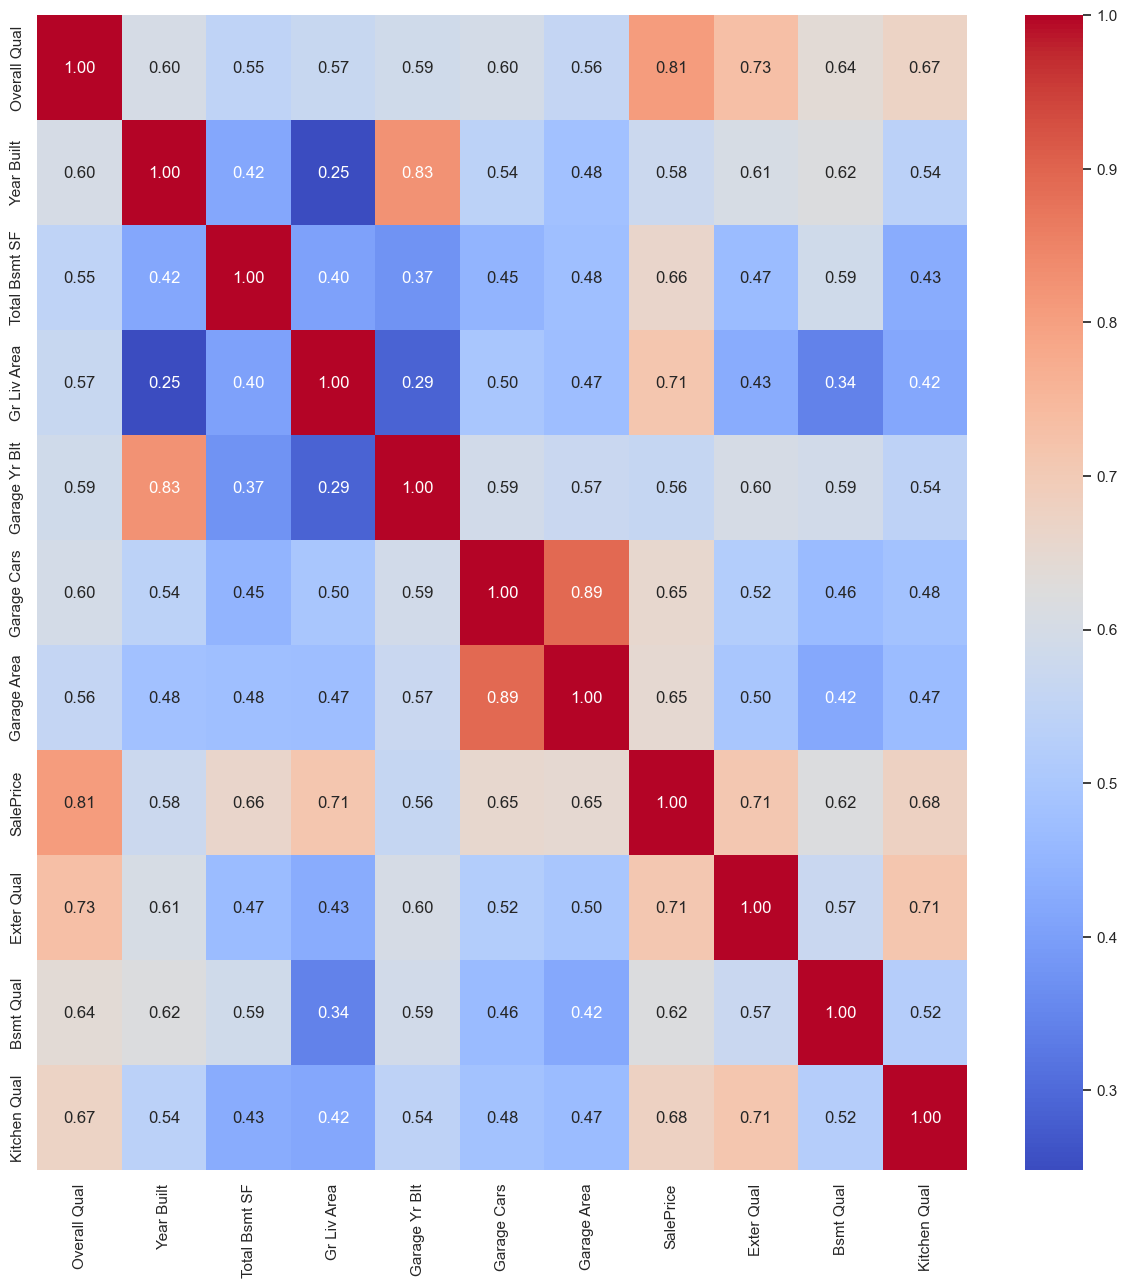

In [12]:
df_50 = pd.DataFrame()
for col in dff.columns:
    if df["SalePrice"].corr(dff[col])>= 0.5:
        df_50[col] = dff[col]
display(df_50.info())
display(df_50)
plt.figure(figsize=(15, 15))
sns.heatmap(df_50.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### 🛡️ Addressing Multicollinearity: Feature Redundancy Filtering

A common challenge in high-dimensional datasets is **Multicollinearity**, which occurs when two or more independent variables are highly correlated with each other. This redundancy can destabilize the regression model and make it difficult to determine the individual impact of each feature on the `SalePrice`.

To solve this, we implement a custom logic to prune our feature set:
* **The Logic:** We inspect pairs of features that show a high mutual correlation.
* **The Decision:** Between two highly correlated features, we retain the one that has a stronger correlation with our target label (`SalePrice`) and drop the other.
* **The Benefit:** This process simplifies the model, reduces computational complexity, and ensures that each remaining feature provides unique, non-redundant information, leading to more stable and reliable coefficient estimates.

In [13]:
def drop_redundant_features_dynamic(df, target_col):
    corr = df.corr(numeric_only=True).abs()

    target_corr = corr[target_col].drop(target_col)
    cols = [c for c in corr.columns if c != target_col]

    to_drop = set()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]

            if c1 in to_drop or c2 in to_drop:
                continue

            pair_corr = corr.loc[c1, c2]
            c1_target = target_corr[c1]
            c2_target = target_corr[c2]

            # Drop if the two features are more correlated with each other
            # than either is with the target
            if pair_corr > c1_target and pair_corr > c2_target:
                if c1_target < c2_target:
                    to_drop.add(c1)
                else:
                    to_drop.add(c2)

    reduced_df = df.drop(columns=list(to_drop))
    return reduced_df

In [14]:
red_df = drop_redundant_features_dynamic(df_50, "SalePrice")
display(df_50)
red_df

,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Yr Blt,Garage Cars,Garage Area,SalePrice,Exter Qual,Bsmt Qual,Kitchen Qual
0,6.0,1960.0,1080.0,1656.0,1960.0,2.0,528.0,215000.0,3.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1961.0,1.0,730.0,105000.0,3.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1958.0,1.0,312.0,172000.0,3.0,3.0,4.0
3,7.0,1968.0,2110.0,2110.0,1968.0,2.0,522.0,244000.0,4.0,3.0,5.0
4,5.0,1997.0,928.0,1629.0,1997.0,2.0,482.0,189900.0,3.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,1984.0,2.0,588.0,142500.0,3.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,1983.0,2.0,484.0,131000.0,3.0,4.0,3.0
2917,5.0,1992.0,912.0,970.0,1962.5,0.0,0.0,132000.0,3.0,4.0,3.0
2918,5.0,1974.0,1389.0,1389.0,1975.0,2.0,418.0,170000.0,3.0,4.0,3.0


,Overall Qual,Year Built,Total Bsmt SF,Gr Liv Area,Garage Cars,SalePrice,Exter Qual,Bsmt Qual
0,6.0,1960.0,1080.0,1656.0,2.0,215000.0,3.0,3.0
1,5.0,1961.0,882.0,896.0,1.0,105000.0,3.0,3.0
2,6.0,1958.0,1329.0,1329.0,1.0,172000.0,3.0,3.0
3,7.0,1968.0,2110.0,2110.0,2.0,244000.0,4.0,3.0
4,5.0,1997.0,928.0,1629.0,2.0,189900.0,3.0,4.0
...,...,...,...,...,...,...,...,...
2915,6.0,1984.0,1003.0,1003.0,2.0,142500.0,3.0,3.0
2916,5.0,1983.0,864.0,902.0,2.0,131000.0,3.0,4.0
2917,5.0,1992.0,912.0,970.0,0.0,132000.0,3.0,4.0
2918,5.0,1974.0,1389.0,1389.0,2.0,170000.0,3.0,4.0


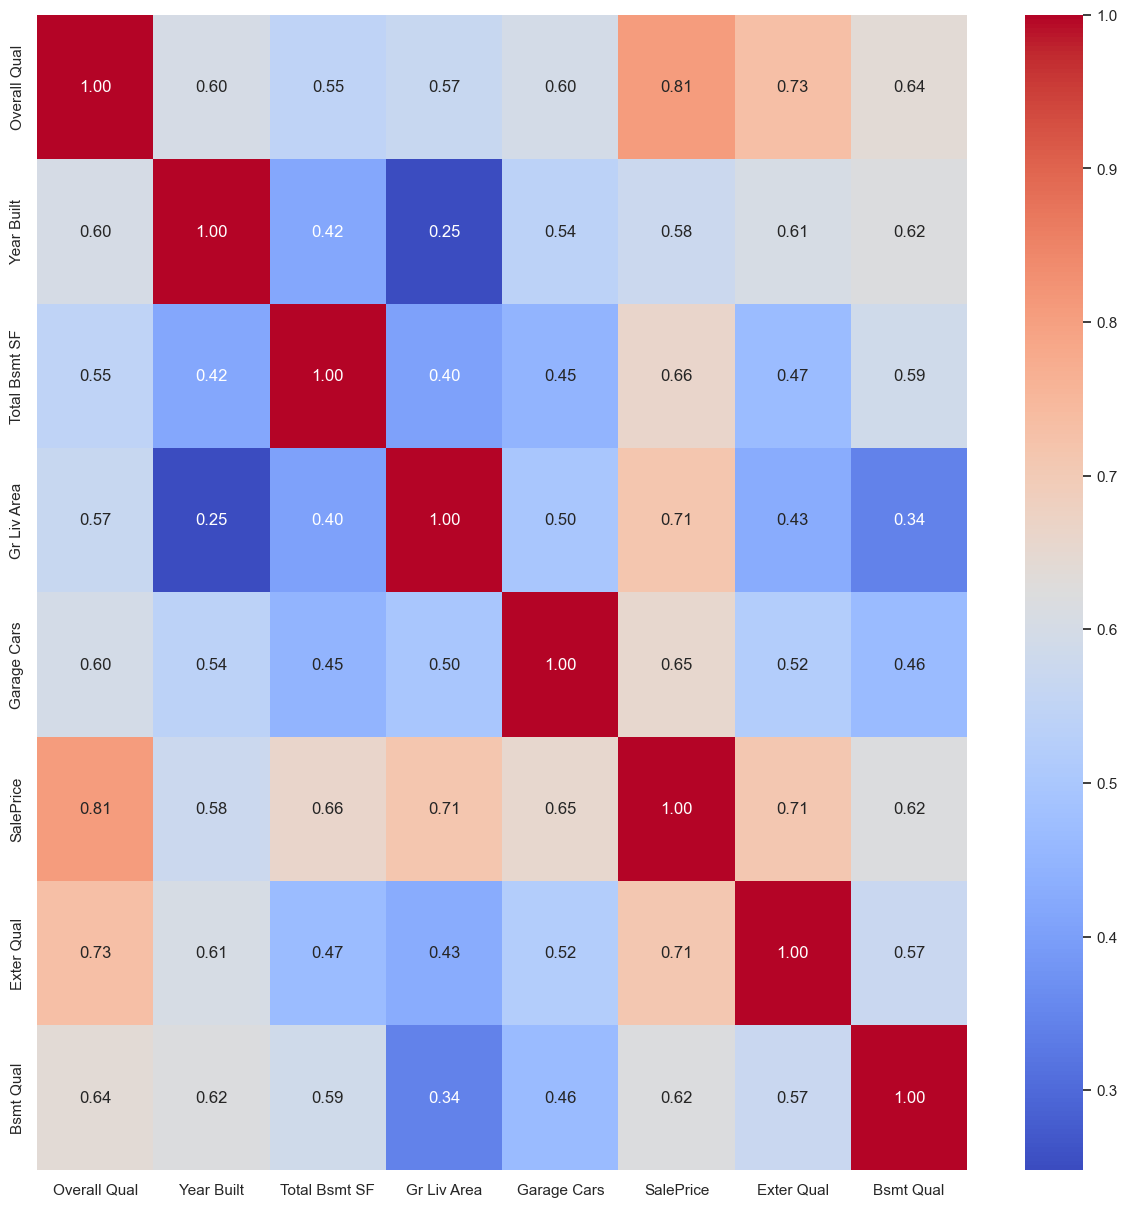

In [15]:
plt.figure(figsize=(15, 15))
sns.heatmap(red_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## 🧪 Model Training & Automated Evaluation Framework

To determine the most accurate algorithm for our house price prediction, we will evaluate three different models. To ensure consistency and efficiency, we have developed a **Comprehensive Evaluation Function**. 

This function acts as a standardized testing bench that performs the following for every model:
1. **Training & Prediction:** Fits the model to the training data and generates predictions on the test set.
2. **Multi-Metric Assessment:** Calculates $R^2$, MAE, RMSE, and MAPE to provide a 360-degree view of performance.
3. **K-Fold Cross-Validation:** Executes a 5-fold split to verify the model's stability and ensure the results are not due to a lucky data split.
4. **Error Visualization:** Generates dual residual plots (Absolute and Percentage errors) to visually inspect where the model succeeds or struggles.

By using this automated framework, we eliminate manual repetition and ensure that our comparison between **Linear Regression**, **SVR**, and **KNN** is strictly objective and scientifically sound.

In [16]:
def evaluate_and_plot_model(model, model_name, x_train, x_test, y_train, y_test, x, y):
    print(f"🚀 ========== Evaluating Model: {model_name} ==========\n")
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    r_squared = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    relative_rmse = rmse / np.mean(y_test)
    
    print("📊 1. Model Scores (Test Set):")
    print(f"R-squared (R2): {r_squared:.4f}")
    print(f"MAE: {mae:,.2f}")
    print(f"MAPE: {mape:.2%}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"Relative RMSE: {relative_rmse:.2%}\n")
    
    residuals = y_test - y_pred
    percentage_residuals = (residuals / y_test) * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='teal', ax=axes[0])
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0].axhspan(-25000, 25000, color='green', alpha=0.1, label='Acceptable Margin (+/- $25K)')
    
    formatter_k = ticker.FuncFormatter(lambda val, pos: f'${val/1000:,.0f}K')
    axes[0].xaxis.set_major_formatter(formatter_k)
    axes[0].yaxis.set_major_formatter(formatter_k)
    
    axes[0].set_title(f'Absolute Residuals (R² = {r_squared:.3f})', fontsize=14)
    axes[0].set_xlabel('Predicted Price', fontsize=12)
    axes[0].set_ylabel('Prediction Error ($)', fontsize=12)
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    
    sns.scatterplot(x=y_pred, y=percentage_residuals, alpha=0.5, color='purple', ax=axes[1])
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].axhspan(-10, 10, color='green', alpha=0.1, label='Acceptable Error (+/- 10%)')
    
    axes[1].xaxis.set_major_formatter(formatter_k)
    formatter_pct = ticker.FuncFormatter(lambda val, pos: f'{val:.0f}%')
    axes[1].yaxis.set_major_formatter(formatter_pct)
    
    axes[1].set_title('Percentage Error vs Predicted Price', fontsize=14)
    axes[1].set_xlabel('Predicted Price', fontsize=12)
    axes[1].set_ylabel('Error Percentage (%)', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 2. Cross Validation Scores (5 Folds):")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    r2_scores = cross_val_score(model, x, y, cv=kf, scoring='r2')
    mape_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    rmse_scores = -cross_val_score(model, x, y, cv=kf, scoring='neg_root_mean_squared_error')
    relative_rmse_scores = (rmse_scores / y.mean()) * 100
    
    print("-" * 75)
    print(f"{'Fold':<8} | {'R² Score':<12} | {'MAPE (%)':<12} | {'Rel. RMSE (%)':<15}")
    print("-" * 75)
    for i in range(len(r2_scores)):
        print(f"Fold {i+1:<4} | {r2_scores[i]:<12.4f} | {mape_scores[i]:<12.2%} | {relative_rmse_scores[i]:<15.2f}%")
    print("-" * 75)
    print(f"📈 Average R² Score      : {r2_scores.mean():.4f} (± {r2_scores.std():.4f}) ---> Deviation")
    print(f"📉 Average MAPE          : {mape_scores.mean():.2%}")
    print(f"📉 Average Relative Error: {relative_rmse_scores.mean():.2f}%\n")
    print("="*75 + "\n")
    return {
        'Model': model_name,
        'R2': r2_scores.mean(),
        'MAPE': mape_scores.mean(),
        'Std': r2_scores.std()
    }

### 🚀 The Advanced Modeling Engine: Pipeline & Target Transformation

In this crucial step, we don't just train a model; we build a **Unified Prediction Framework** using Scikit-Learn's `Pipeline` and `TransformedTargetRegressor`. This approach is designed to squeeze the maximum performance out of our algorithms through two main strategies:

1. **Feature Scaling (MinMaxScaler):** Since we are using distance-based models like **KNN** and **SVR**, scaling is mandatory. This process squeezes all input features into a range between 0 and 1, ensuring that features with large numbers (like `Lot Area`) don't overwhelm features with small numbers (like `Full Bath`).

2. **Target Normalization (Log Transformation):** House prices are often "positively skewed" (meaning there are many average houses and a few very expensive ones). This skewness can confuse regression models. 
   * **The Solution:** We apply a **Logarithmic Transformation** ($log(1+x)$) to the target label. This "squeezes" the price range, making the data distribution more normal (bell-shaped) and much easier for the model to learn accurately.
   * **The Result:** The model predicts in the log-scale, and the `TransformedTargetRegressor` automatically applies the **Exponential Inverse** ($e^x - 1$) to return the final answer in actual dollars.



This combination ensures that our models are mathematically optimized and that our predictions are grounded in stabilized, normalized data.

* **Importing necessary classes**
* **Splitting Data**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import matplotlib.ticker as ticker
from sklearn.model_selection import KFold, cross_val_score
x = red_df.drop(columns = "SalePrice")
y = red_df["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(x,y,train_size=0.8 , random_state = 2)

## Coding models & Sacaling Data

In [18]:
lr_pipeline = make_pipeline(MinMaxScaler(), LinearRegression())
lr_model = TransformedTargetRegressor(
    regressor=lr_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
svr_pipeline = make_pipeline(MinMaxScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))
svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5))
knn_model = TransformedTargetRegressor(
    regressor=knn_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [19]:
# evaluate_and_plot_model(lr_model, "Linear Regression (with Pipeline & Target Transform)", X_train, X_test, y_train, y_test, x, y)

In [20]:
# evaluate_and_plot_model(svr_model, "SVR (with Pipeline & Target Transform)", X_train, X_test, y_train, y_test, x, y)

In [21]:
# evaluate_and_plot_model(knn_model, "KNN (with Pipeline & Target Transform)", X_train, X_test, y_train, y_test, x, y)

## Gathering Models info

🚀 ========== Evaluating Model: Linear Regression ==========

📊 1. Model Scores (Test Set):
R-squared (R2): 0.8825
MAE: 18,487.76
MAPE: 11.03%
RMSE: 25,902.62
Relative RMSE: 14.43%



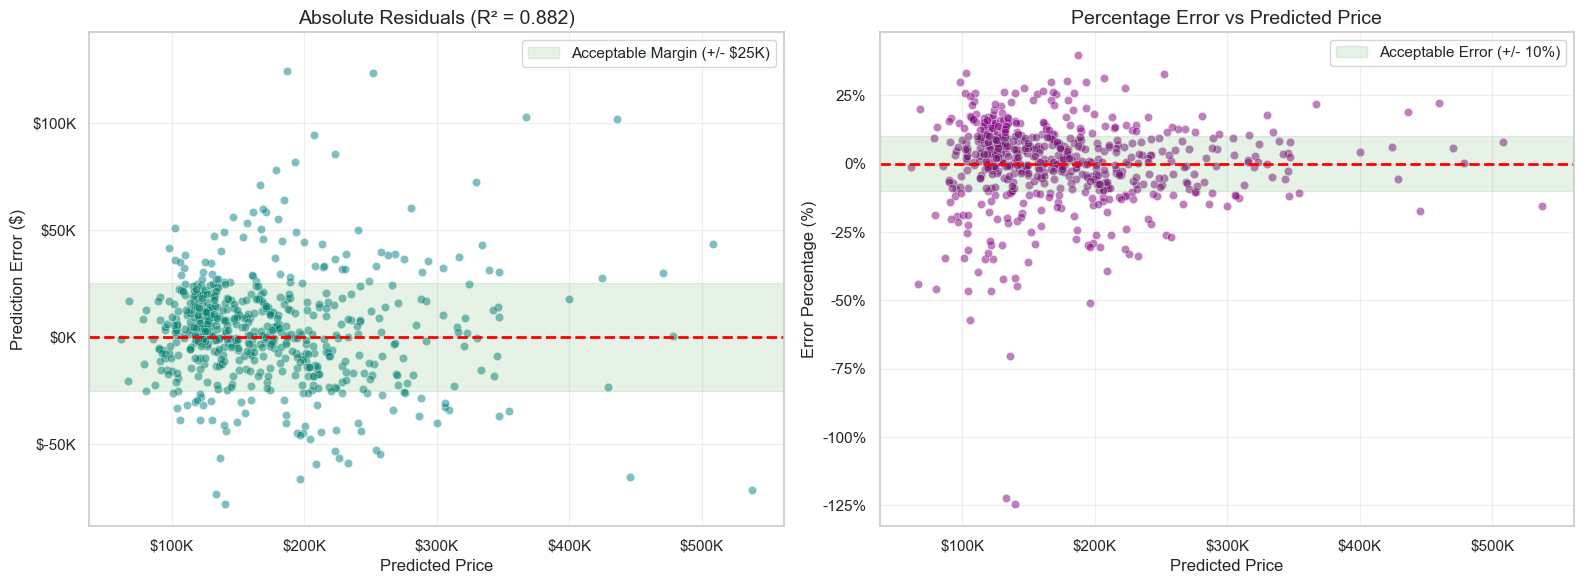


📊 2. Cross Validation Scores (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8994       | 11.00%       | 15.07          %
Fold 2    | 0.8750       | 11.31%       | 14.25          %
Fold 3    | 0.8781       | 13.12%       | 14.19          %
Fold 4    | 0.8723       | 11.97%       | 14.99          %
Fold 5    | 0.8758       | 11.32%       | 15.62          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8801 (± 0.0098) ---> Deviation
📉 Average MAPE          : 11.74%
📉 Average Relative Error: 14.82%


🚀 ========== Evaluating Model: SVR ==========

📊 1. Model Scores (Test Set):
R-squared (R2): 0.8424
MAE: 20,145.13
MAPE: 11.95%
RMSE: 29,994.70
Relative RMSE: 16.71%



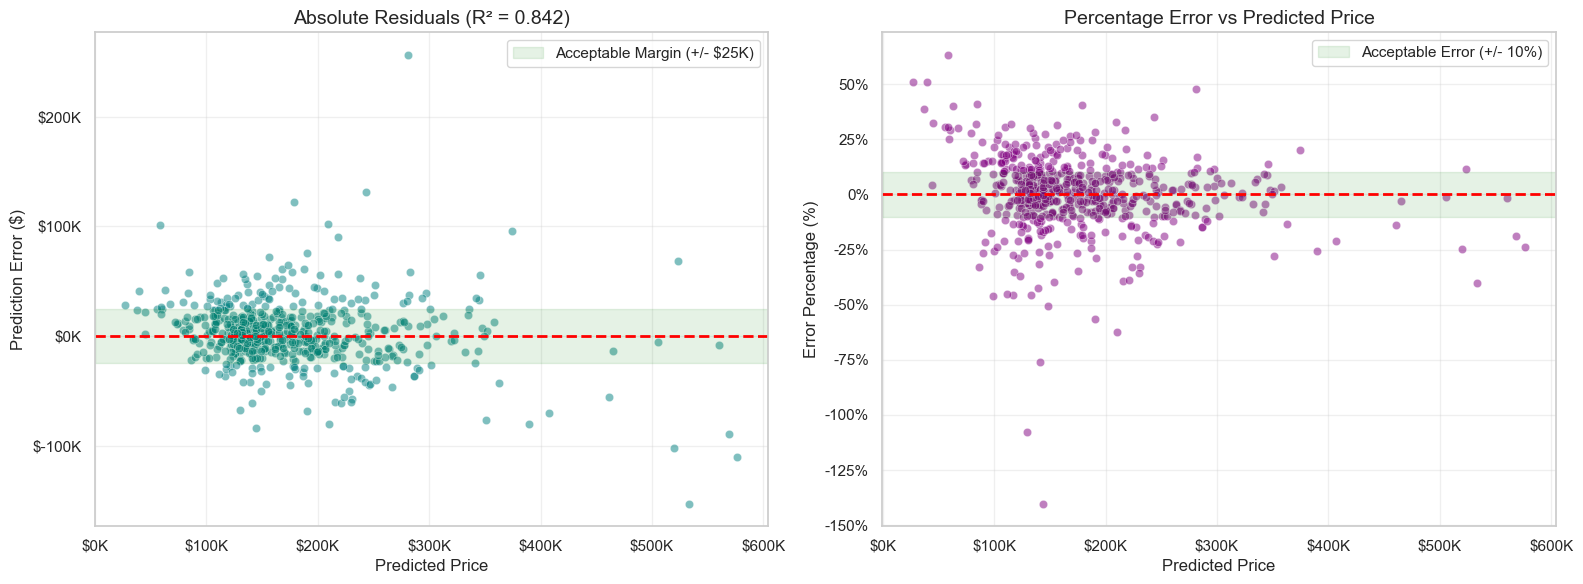


📊 2. Cross Validation Scores (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8932       | 10.90%       | 15.53          %
Fold 2    | 0.8208       | 11.98%       | 17.05          %
Fold 3    | 0.8162       | 13.06%       | 17.43          %
Fold 4    | 0.8288       | 12.11%       | 17.35          %
Fold 5    | 0.7908       | 12.27%       | 20.27          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8300 (± 0.0341) ---> Deviation
📉 Average MAPE          : 12.06%
📉 Average Relative Error: 17.53%


🚀 ========== Evaluating Model: KNN ==========

📊 1. Model Scores (Test Set):
R-squared (R2): 0.8727
MAE: 19,347.34
MAPE: 11.62%
RMSE: 26,958.73
Relative RMSE: 15.02%



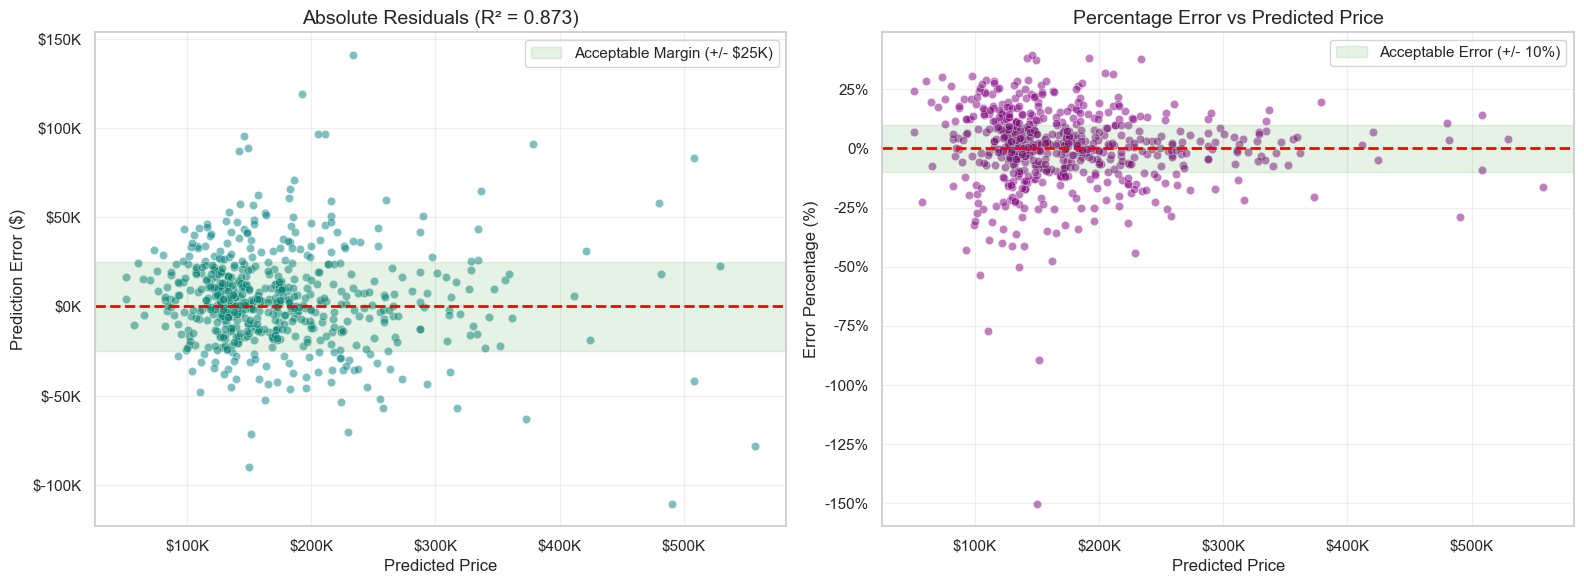


📊 2. Cross Validation Scores (5 Folds):
---------------------------------------------------------------------------
Fold     | R² Score     | MAPE (%)     | Rel. RMSE (%)  
---------------------------------------------------------------------------
Fold 1    | 0.8861       | 11.40%       | 16.04          %
Fold 2    | 0.8507       | 11.64%       | 15.57          %
Fold 3    | 0.8647       | 13.28%       | 14.96          %
Fold 4    | 0.8702       | 11.55%       | 15.11          %
Fold 5    | 0.8534       | 11.84%       | 16.97          %
---------------------------------------------------------------------------
📈 Average R² Score      : 0.8650 (± 0.0128) ---> Deviation
📉 Average MAPE          : 11.94%
📉 Average Relative Error: 15.73%




In [22]:
all_results = []

all_results.append(evaluate_and_plot_model(lr_model, "Linear Regression", X_train, X_test, y_train, y_test, x, y))
all_results.append(evaluate_and_plot_model(svr_model, "SVR", X_train, X_test, y_train, y_test, x, y))
all_results.append(evaluate_and_plot_model(knn_model, "KNN", X_train, X_test, y_train, y_test, x, y))

In [23]:
from IPython.display import display, Markdown

winner = max(all_results, key=lambda x: x['R2'])

table_rows = ""
for res in all_results:
    stability = "Low (Stable)" if res['Std'] < 0.05 else "High (Unstable)"
    table_rows += f"| **{res['Model']}** | {res['R2']:.4f} | {res['MAPE']:.2%} | {stability} ({res['Std']:.4f}) |\n"

markdown_content = f"""
## 🏆 Final Model Comparison & Performance Synthesis

This table updates automatically based on your latest model parameters and random seeds.

| Model | Avg. $R^2$ Score | Avg. MAPE (%) | Stability (CV Std Dev) |
| :--- | :---: | :---: | :---: |
{table_rows}

### 🏁 The Verdict

* **The Winner:** Based on the current run, the **{winner['Model']}** is the best performer with an $R^2$ of **{winner['R2']:.4f}**.
* **Model Stability:** The standard deviation metrics confirm the reliability of these results across 5 different folds.
"""

display(Markdown(markdown_content))


## 🏆 Final Model Comparison & Performance Synthesis

This table updates automatically based on your latest model parameters and random seeds.

| Model | Avg. $R^2$ Score | Avg. MAPE (%) | Stability (CV Std Dev) |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | 0.8801 | 11.74% | Low (Stable) (0.0098) |
| **SVR** | 0.8300 | 12.06% | Low (Stable) (0.0341) |
| **KNN** | 0.8650 | 11.94% | Low (Stable) (0.0128) |


### 🏁 The Verdict

* **The Winner:** Based on the current run, the **Linear Regression** is the best performer with an $R^2$ of **0.8801**.
* **Model Stability:** The standard deviation metrics confirm the reliability of these results across 5 different folds.


📊 Automated Model Comparison Table:


,Model,R² Score,MAPE (%),CV Std Dev
0,Linear Regression,0.880121,11.744908,0.009834
1,SVR,0.829974,12.062122,0.034096
2,KNN,0.865007,11.944138,0.012751


C:\Users\Al-Rowad\AppData\Local\Temp\ipykernel_36032\3315597871.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R² Score', y='Model', data=df_results, palette='viridis', ax=axes[0])
C:\Users\Al-Rowad\AppData\Local\Temp\ipykernel_36032\3315597871.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAPE (%)', y='Model', data=df_results, palette='magma', ax=axes[1])


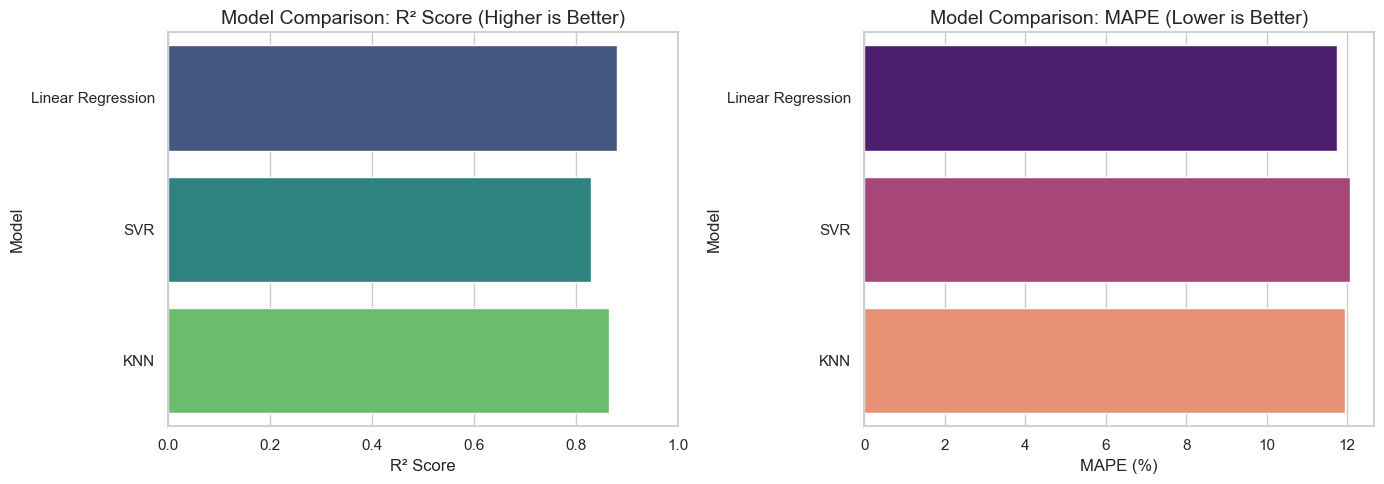

In [24]:
df_results = pd.DataFrame(all_results)

df_results = df_results.rename(columns={
    'R2': 'R² Score',
    'MAPE': 'MAPE (%)',
    'Std': 'CV Std Dev'
})

if df_results['MAPE (%)'].max() < 1.5:  
    df_results['MAPE (%)'] = df_results['MAPE (%)'] * 100

print("📊 Automated Model Comparison Table:")
display(df_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='R² Score', y='Model', data=df_results, palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=14)
axes[0].set_xlim(0, 1)

sns.barplot(x='MAPE (%)', y='Model', data=df_results, palette='magma', ax=axes[1])
axes[1].set_title('Model Comparison: MAPE (Lower is Better)', fontsize=14)

plt.tight_layout()
plt.show()

In [25]:
import joblib
joblib.dump(lr_model, "model.pkl")

['model.pkl']

## تمت بحمد الله